# Preoperative HbA1c CDS Reproducible Workflow

This notebook is the shareable procedure for the pre-surgical HbA1c risk workflow. It is organized so a reviewer can run it without institutional credentials using the sample data path, then switch to Cosmos-backed data by providing environment variables from `.env.example`.

Default behavior uses sample data and generates reviewable FHIR resources without sending alerts.

## Author & Acknowledgments

Corresponding author: David Balkcom, MPH, Principal Data Engineer, Quality Measurement Group, IT Vendor Services, United States. Contact: castle.palaces8l@icloud.com.

Acknowledgments: Andrea Pitkus, PhD.

## HbA1c Specimen Clarification

A serum HbA1c test method does not exist. HbA1c measures the glucose attached to hemoglobin, which is a protein found strictly inside red blood cells. Serum is the liquid portion of the blood after the red blood cells and clotting factors have been removed, meaning it contains no hemoglobin to test. For HbA1c testing, a whole blood sample (which includes red blood cells) is always required. Laboratories process this using methods like HPLC (High-Performance Liquid Chromatography) or immunoassays.

## Example External Lab Value Flow

The flow below summarizes how external HbA1c values move from EHI or another clinical source into the preoperative CDS workflow.

```mermaid
flowchart TD
    A["EHI or External Clinical Source"] --> B["FHIR Observation<br/>HbA1c LOINC 4548-4"]
    B --> C["Azure Cosmos DB<br/>Clinical data layer"]
    C --> D["Observation.valueQuantity %<br/>Observation.effectiveDateTime"]
    D --> E["Pre-op HbA1c CDS Pipeline"]
    E --> F["Risk Tiering<br/>info / warning / critical"]
    F --> G["FHIR-ready CDS Resources<br/>CommunicationRequest / Task"]
    G --> H["Epic workflow integration review"]
```

## Procedure

1. Load the pipeline code and runtime configuration.
2. Select the data source: sample data for replication or Cosmos for local execution.
3. Validate the cohort, HbA1c lab, and vitals fields needed by the workflow.
4. Merge patient, lab, and vitals records into one analytic table.
5. Optionally estimate missing HbA1c values if a training set and `adelie` are available.
6. Apply HbA1c risk tiers: Low `<7.5`, Medium `7.5-8.5`, High `>8.5` by default.
7. Map tiers to CDS workflow actions and FHIR artifact previews.
8. Save run metadata and compact outputs for review.

## Environment Setup

Run the next cell first. It creates `.venv` in the repository root when needed, installs the base runtime dependencies there, exposes that environment to the active notebook session, and then continues with the workflow.

`adelie` is optional and only needed when `RUN_PREDICTION=true`. On macOS it requires OpenMP first, for example `libomp` via Homebrew or `llvm-openmp` via conda.

In [8]:
from __future__ import annotations

import importlib
import importlib.util
import json
import os
import platform
import subprocess
import sys
import venv
from datetime import date
from pathlib import Path

PIPELINE_FILE = "preop_hba1c_cds_workflow.py"
candidate_roots = [Path.cwd(), *Path.cwd().parents]
REPO_ROOT = next((path for path in candidate_roots if (path / PIPELINE_FILE).exists()), None)
if REPO_ROOT is None:
    searched = ", ".join(str(path) for path in candidate_roots)
    raise FileNotFoundError(f"Could not find {PIPELINE_FILE}. Searched: {searched}")

VENV_DIR = REPO_ROOT / ".venv"
VENV_PYTHON = VENV_DIR / ("Scripts/python.exe" if os.name == "nt" else "bin/python")
BASE_DEPENDENCIES = ["python-dotenv", "pandas", "numpy", "requests", "matplotlib", "azure-cosmos"]
REQUIRED_MODULES = ["dotenv", "pandas", "numpy", "requests", "matplotlib", "azure.cosmos"]


def run_command(command: list[str]) -> None:
    print("$ " + " ".join(command))
    subprocess.check_call(command)


def venv_site_packages() -> list[str]:
    script = "import json, site; print(json.dumps(site.getsitepackages()))"
    output = subprocess.check_output([str(VENV_PYTHON), "-c", script], text=True)
    return json.loads(output)


def missing_modules(python_executable: Path) -> list[str]:
    script = (
        "import importlib.util, json; "
        f"mods = {json.dumps(REQUIRED_MODULES)}; "
        "print(json.dumps([m for m in mods if importlib.util.find_spec(m) is None]))"
    )
    output = subprocess.check_output([str(python_executable), "-c", script], text=True)
    return json.loads(output)


if not VENV_PYTHON.exists():
    print(f"Creating notebook environment at {VENV_DIR}")
    venv.EnvBuilder(with_pip=True).create(VENV_DIR)

missing_in_venv = missing_modules(VENV_PYTHON)
if missing_in_venv:
    print(f"Installing notebook dependencies for missing modules: {missing_in_venv}")
    run_command([str(VENV_PYTHON), "-m", "pip", "install", "--upgrade", "pip"])
    run_command([str(VENV_PYTHON), "-m", "pip", "install", *BASE_DEPENDENCIES])

for site_dir in reversed(venv_site_packages()):
    if site_dir not in sys.path:
        sys.path.insert(0, site_dir)

importlib.invalidate_caches()
missing_in_kernel = [module for module in REQUIRED_MODULES if importlib.util.find_spec(module) is None]
if missing_in_kernel:
    raise RuntimeError(f"Notebook environment is missing modules after install: {missing_in_kernel}")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from dotenv import load_dotenv

if load_dotenv is not None:
    load_dotenv(REPO_ROOT / ".env")

pipeline_path = REPO_ROOT / PIPELINE_FILE
spec = importlib.util.spec_from_file_location("preop_hba1c_pipeline", pipeline_path)
pipeline = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = pipeline
spec.loader.exec_module(pipeline)

print(f"Repo root: {REPO_ROOT}")
print(f"Pipeline source: {pipeline_path.name}")
print(f"Dependency environment: {VENV_DIR}")

Repo root: /Users/davidbrian/.qmg/skunkworks-preop-risk-hba1c
Pipeline source: preop_hba1c_cds_workflow.py
Dependency environment: /Users/davidbrian/.qmg/skunkworks-preop-risk-hba1c/.venv


## Parameters

Use `DATA_SOURCE=sample` for a portable run. Use `DATA_SOURCE=cosmos` after setting the Cosmos variables in `.env` or the execution environment. The notebook keeps `DRY_RUN=True` so FHIR resources are generated for review only.

In [9]:
DATA_SOURCE = os.getenv("DATA_SOURCE", "sample").strip().lower()
PREOP_DATE = os.getenv("PREOP_DATE", "2026-05-01").strip()
SAMPLE_COHORT_JSON = REPO_ROOT / os.getenv("SAMPLE_COHORT_JSON", "sample-hba1c-cohort.json").strip()

LOW_THRESHOLD = float(os.getenv("HBA1C_LOW_THRESHOLD", "7.5"))
HIGH_THRESHOLD = float(os.getenv("HBA1C_HIGH_THRESHOLD", "8.5"))

RUN_PREDICTION = os.getenv("RUN_PREDICTION", "false").strip().lower() in {"1", "true", "yes"}
TRAINING_CSV = os.getenv("TRAINING_CSV") or None

DRY_RUN = True

config = {
    "data_source": DATA_SOURCE,
    "preop_date": PREOP_DATE,
    "low_threshold": LOW_THRESHOLD,
    "high_threshold": HIGH_THRESHOLD,
    "run_prediction": RUN_PREDICTION,
    "training_csv": TRAINING_CSV,
    "sample_cohort_json": str(SAMPLE_COHORT_JSON.relative_to(REPO_ROOT)),
    "dry_run": DRY_RUN,
}
config

{'data_source': 'sample',
 'preop_date': '2026-05-01',
 'low_threshold': 7.5,
 'high_threshold': 8.5,
 'run_prediction': False,
 'training_csv': None,
 'sample_cohort_json': 'sample-hba1c-cohort.json',
 'dry_run': True}

## Load Data

The sample data is loaded from `sample-hba1c-cohort.json`. It mirrors the expected shape of the Cosmos query outputs and covers each risk tier plus unknown HbA1c cases without sending sample patient data.

In [10]:
def require_env(name: str) -> str:
    value = os.getenv(name, "").strip()
    if not value:
        raise RuntimeError(f"Missing required environment variable: {name}")
    return value


if DATA_SOURCE == "cosmos":
    settings = pipeline.Settings(
        data_source="cosmos",
        sample_cohort_json=str(SAMPLE_COHORT_JSON),
        cosmos_url=require_env("COSMOS_URL"),
        cosmos_key=require_env("COSMOS_KEY"),
        database_id=require_env("DATABASE_ID"),
        container_patient=os.getenv("CONTAINER_PATIENT", "PATIENT").strip(),
        container_labs=os.getenv("CONTAINER_LABS", "NSQIP_PREOP_LABS").strip(),
        container_vitals=os.getenv("CONTAINER_VITALS", "PREOP_VITALS").strip(),
        fhir_base=os.getenv("FHIR_BASE", "").strip(),
        oauth_bearer=os.getenv("OAUTH_BEARER", "").strip(),
        preop_date=PREOP_DATE,
        low_threshold=LOW_THRESHOLD,
        high_threshold=HIGH_THRESHOLD,
        H=None,
        delta=None,
        dry_run=DRY_RUN,
        plot=False,
        training_csv=TRAINING_CSV,
        enable_prediction=RUN_PREDICTION,
    )
    client = pipeline.cosmos_client(settings)
    db = client.get_database_client(settings.database_id)
    df_pat = pipeline.load_preop_cohort(db, settings)
    df_labs = pipeline.load_a1c_labs(db, settings)
    df_vitals = pipeline.load_vitals(db, settings)
else:
    settings = None
    df_pat, df_labs, df_vitals = pipeline.load_sample_data(SAMPLE_COHORT_JSON, PREOP_DATE)

print({"patients": len(df_pat), "labs": len(df_labs), "vitals": len(df_vitals), "identifier": pipeline.IDENTIFIER_COL})

{'patients': 64, 'labs': 56, 'vitals': 64, 'identifier': 'pat_eid'}


## Validate Inputs

These checks make the notebook fail early if an exported or queried dataset is missing fields needed by downstream logic.

In [11]:
required_columns = {
    "patient": {"pat_eid", "encounter_id", "preop_date", "birthdate", "gender", "surgical_risk"},
    "labs": {"pat_eid", "a1c", "lab_time"},
    "vitals": {"pat_eid", "sbp", "dbp", "bmi", "vitals_time"},
}

frames = {"patient": df_pat, "labs": df_labs, "vitals": df_vitals}
for name, required in required_columns.items():
    missing = sorted(required.difference(frames[name].columns))
    if missing:
        raise ValueError(f"{name} data is missing columns: {missing}")

if df_pat.empty:
    raise ValueError(f"No pre-op cohort found for PREOP_DATE={PREOP_DATE}")

print("Input validation passed")

Input validation passed


## Build Analytic Table

Patient records define the cohort. Lab and vitals records are left-joined so missing HbA1c remains visible and can be handled explicitly.

In [12]:
analysis_df = df_pat.merge(df_labs, on="pat_eid", how="left").merge(df_vitals, on="pat_eid", how="left")
analysis_df = pipeline.add_age(analysis_df)

analysis_df["a1c"] = pd.to_numeric(analysis_df["a1c"], errors="coerce")
analysis_df["lab_time"] = pd.to_datetime(analysis_df["lab_time"], errors="coerce", utc=True)
analysis_df["vitals_time"] = pd.to_datetime(analysis_df["vitals_time"], errors="coerce", utc=True)

analysis_df

,pat_eid,encounter_id,preop_date,birthdate,gender,surgical_risk,loinc,a1c,unit,lab_time,sbp,dbp,bmi,vitals_time,age
0,PAT-EID-0001,ENC-20260501-0001,2026-05-01,1973-07-15,male,low,4548-4,6.7,%,2026-04-13 09:25:00+00:00,109,68,22.6,2026-05-01 06:03:00+00:00,52.9
1,PAT-EID-0002,ENC-20260501-0002,2026-05-01,1990-05-08,female,low,4548-4,8.3,%,2026-04-04 13:04:00+00:00,134,76,28.7,2026-05-01 06:06:00+00:00,36.1
2,PAT-EID-0003,ENC-20260501-0003,2026-05-01,1959-06-26,female,low,4548-4,9.8,%,2026-04-22 13:56:00+00:00,127,81,25.1,2026-05-01 06:09:00+00:00,66.9
3,PAT-EID-0004,ENC-20260501-0004,2026-05-01,1991-10-19,female,low,4548-4,6.6,%,2026-04-04 16:33:00+00:00,120,70,32.0,2026-05-01 06:12:00+00:00,34.6
4,PAT-EID-0005,ENC-20260501-0005,2026-05-01,1946-07-11,male,moderate,4548-4,8.2,%,2026-04-11 14:18:00+00:00,125,84,28.8,2026-05-01 06:15:00+00:00,79.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,PAT-EID-0060,ENC-20260501-0060,2026-05-01,1959-11-19,female,low,4548-4,10.1,%,2026-04-08 16:09:00+00:00,132,77,29.9,2026-05-01 09:00:00+00:00,66.5
60,PAT-EID-0061,ENC-20260501-0061,2026-05-01,1979-09-08,female,moderate,4548-4,7.1,%,2026-04-20 14:51:00+00:00,136,83,31.0,2026-05-01 09:03:00+00:00,46.7
61,PAT-EID-0062,ENC-20260501-0062,2026-05-01,1950-01-20,male,high,4548-4,8.1,%,2026-04-25 09:17:00+00:00,157,98,43.5,2026-05-01 09:06:00+00:00,76.4
62,PAT-EID-0063,ENC-20260501-0063,2026-05-01,1989-06-26,female,moderate,4548-4,10.0,%,2026-04-03 09:26:00+00:00,133,89,30.6,2026-05-01 09:09:00+00:00,36.9


## Optional Missing HbA1c Estimation

Prediction is disabled by default. Enable it only when the execution environment has `adelie` and either enough in-scope measured HbA1c rows or a `TRAINING_CSV` with compatible columns.

In [13]:
model_info = {"trained": False, "reason": "prediction_disabled"}

if RUN_PREDICTION:
    pred_a1c, model_info = pipeline.fit_predict_a1c_with_adelie(analysis_df, TRAINING_CSV)
    analysis_df["a1c_predicted"] = pred_a1c
    analysis_df["a1c_used"] = analysis_df["a1c"].where(analysis_df["a1c"].notna(), analysis_df["a1c_predicted"])
else:
    analysis_df["a1c_predicted"] = np.nan
    analysis_df["a1c_used"] = analysis_df["a1c"]

model_info

{'trained': False, 'reason': 'prediction_disabled'}

## Apply Risk Tiers and CDS Actions

Risk tiers are computed from measured HbA1c when present, otherwise from the optional predicted value. Unknown HbA1c values stay unknown rather than being silently treated as low risk.

In [14]:
tiers = analysis_df["a1c_used"].apply(
    lambda value: pipeline.tier_from_a1c(value, LOW_THRESHOLD, HIGH_THRESHOLD)
)

analysis_df["tier"] = tiers.apply(lambda item: item[0])
analysis_df["risk_category"] = tiers.apply(lambda item: item[1])
analysis_df["tier_metrics"] = tiers.apply(lambda item: item[2])
analysis_df["workflow_action"] = analysis_df["tier"].apply(pipeline.workflow_action_from_tier)

analysis_df["cds_message"] = analysis_df.apply(
    lambda row: pipeline.build_comm_payload(
        float(row["tier_metrics"]["a1c_used"])
        if not np.isnan(row["tier_metrics"]["a1c_used"])
        else np.nan,
        row["tier"],
        row["tier_metrics"],
    ),
    axis=1,
)

summary_cols = [
    "pat_eid",
    "encounter_id",
    "preop_date",
    "a1c",
    "a1c_predicted",
    "a1c_used",
    "risk_category",
    "workflow_action",
    "cds_message",
]
analysis_df[summary_cols]

,pat_eid,encounter_id,preop_date,a1c,a1c_predicted,a1c_used,risk_category,workflow_action,cds_message
0,PAT-EID-0001,ENC-20260501-0001,2026-05-01,6.7,NaN,6.7,Low,Info,Pre-op HbA1c 6.70% (< 7.50%). **Low risk**. In...
1,PAT-EID-0002,ENC-20260501-0002,2026-05-01,8.3,NaN,8.3,Medium,Warn,Pre-op HbA1c 8.30% (7.50–8.50%). **Medium risk...
2,PAT-EID-0003,ENC-20260501-0003,2026-05-01,9.8,NaN,9.8,High,Block,Pre-op HbA1c 9.80% (> 8.50%). **High risk**. S...
3,PAT-EID-0004,ENC-20260501-0004,2026-05-01,6.6,NaN,6.6,Low,Info,Pre-op HbA1c 6.60% (< 7.50%). **Low risk**. In...
4,PAT-EID-0005,ENC-20260501-0005,2026-05-01,8.2,NaN,8.2,Medium,Warn,Pre-op HbA1c 8.20% (7.50–8.50%). **Medium risk...
...,...,...,...,...,...,...,...,...,...
59,PAT-EID-0060,ENC-20260501-0060,2026-05-01,10.1,NaN,10.1,High,Block,Pre-op HbA1c 10.10% (> 8.50%). **High risk**. ...
60,PAT-EID-0061,ENC-20260501-0061,2026-05-01,7.1,NaN,7.1,Low,Info,Pre-op HbA1c 7.10% (< 7.50%). **Low risk**. In...
61,PAT-EID-0062,ENC-20260501-0062,2026-05-01,8.1,NaN,8.1,Medium,Warn,Pre-op HbA1c 8.10% (7.50–8.50%). **Medium risk...
62,PAT-EID-0063,ENC-20260501-0063,2026-05-01,10.0,NaN,10.0,High,Block,Pre-op HbA1c 10.00% (> 8.50%). **High risk**. ...


## Cohort Summary

The bar chart is intentionally simple because this output is meant for quick clinical review and run-to-run comparison.

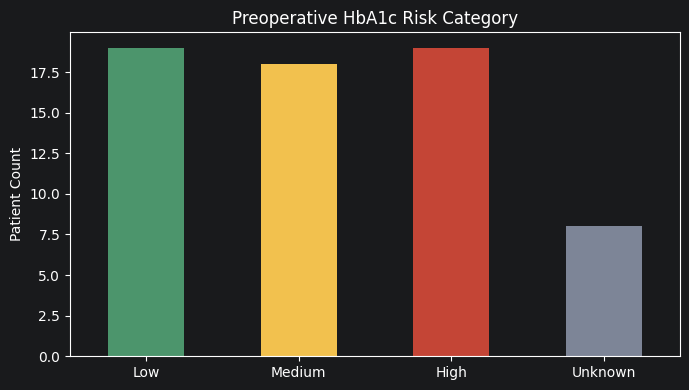

,patient_count
risk_category,
Low,19
Medium,18
High,19
Unknown,8


In [15]:
risk_order = ["Low", "Medium", "High", "Unknown"]
risk_counts = analysis_df["risk_category"].value_counts(dropna=False).reindex(risk_order, fill_value=0)

ax = risk_counts.plot(kind="bar", figsize=(7, 4), color=["#4c956c", "#f2c14e", "#c44536", "#7d8597"])
ax.set_title("Preoperative HbA1c Risk Category")
ax.set_xlabel("")
ax.set_ylabel("Patient Count")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

risk_counts.to_frame(name="patient_count")

## FHIR Preview

This cell previews the FHIR resources that would be posted by the pipeline. It does not call the FHIR endpoint. Critical cases create both a `CommunicationRequest` and a `Task`; non-critical CDS actions create a `CommunicationRequest`.

In [16]:
def preview_fhir_payloads(df: pd.DataFrame) -> list[dict]:
    payloads = []

    for _, row in df.iterrows():
        action = row.get("workflow_action", "None")
        if action == "None":
            continue

        patient_ref = f"Patient/{row['pat_eid']}"
        encounter_ref = f"Encounter/{row['encounter_id']}"

        comm = {
            "resourceType": "CommunicationRequest",
            "status": "active",
            "subject": {"reference": patient_ref},
            "encounter": {"reference": encounter_ref},
            "payload": [{"contentString": row.get("cds_message", "Pre-op risk message")}],
            "reasonCode": [{"text": "Pre-op Glycemic Surgical Risk"}],
        }

        if action == "Block":
            comm["priority"] = "stat"
            comm["category"] = [{"text": "Stop-the-line / Clinical huddle"}]
        elif action == "Warn":
            comm["priority"] = "urgent"
            comm["category"] = [{"text": "Pre-op warning"}]
        elif action == "Info":
            comm["priority"] = "routine"

        payloads.append(comm)

        if action == "Block":
            payloads.append({
                "resourceType": "Task",
                "status": "requested",
                "intent": "order",
                "description": "High surgical diabetes risk - HITL sign-off required.",
                "for": {"reference": patient_ref},
                "encounter": {"reference": encounter_ref},
                "priority": "stat",
            })

    return payloads


fhir_payloads = preview_fhir_payloads(analysis_df)
print(json.dumps(fhir_payloads, indent=2))

[
  {
    "resourceType": "CommunicationRequest",
    "status": "active",
    "subject": {
      "reference": "Patient/PAT-EID-0001"
    },
    "encounter": {
      "reference": "Encounter/ENC-20260501-0001"
    },
    "payload": [
      {
        "contentString": "Pre-op HbA1c 6.70% (< 7.50%). **Low risk**. Info card only. +1.80 HbA1c points below high cutoff."
      }
    ],
    "reasonCode": [
      {
        "text": "Pre-op Glycemic Surgical Risk"
      }
    ],
    "priority": "routine"
  },
  {
    "resourceType": "CommunicationRequest",
    "status": "active",
    "subject": {
      "reference": "Patient/PAT-EID-0002"
    },
    "encounter": {
      "reference": "Encounter/ENC-20260501-0002"
    },
    "payload": [
      {
        "contentString": "Pre-op HbA1c 8.30% (7.50\u20138.50%). **Medium risk**. Trigger Epic warning. +0.20 HbA1c points below high cutoff."
      }
    ],
    "reasonCode": [
      {
        "text": "Pre-op Glycemic Surgical Risk"
      }
    ],
    "priorit

## Run Metadata

Capture the parameters and package versions needed to compare runs across sites.

In [17]:
run_metadata = {
    **config,
    "executed_on": date.today().isoformat(),
    "python": platform.python_version(),
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "matplotlib": getattr(plt.matplotlib, "__version__", "unknown"),
    "pipeline_path": str(pipeline_path.relative_to(REPO_ROOT)),
    "n_patients": int(len(analysis_df)),
    "n_fhir_preview_resources": int(len(fhir_payloads)),
}

print(json.dumps(run_metadata, indent=2))

{
  "data_source": "sample",
  "preop_date": "2026-05-01",
  "low_threshold": 7.5,
  "high_threshold": 8.5,
  "run_prediction": false,
  "training_csv": null,
  "sample_cohort_json": "sample-hba1c-cohort.json",
  "dry_run": true,
  "executed_on": "2026-05-30",
  "python": "3.14.5",
  "pandas": "3.0.2",
  "numpy": "2.4.4",
  "matplotlib": "3.10.8",
  "pipeline_path": "preop_hba1c_cds_workflow.py",
  "n_patients": 64,
  "n_fhir_preview_resources": 75
}
